## Imports

In [1]:
import time
import math
import random
import copy
from collections import defaultdict
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from IPython.display import display

In [2]:
random.seed(42)
np.random.seed(42)

## Load Data

In [3]:
courses_raw = pd.read_csv("..\data\data_final.csv")
rooms_df = pd.read_csv("..\data\Ruang Kuliah.csv")
labs_df = pd.read_csv("..\data\Laboratorium.csv")

courses_raw.columns = [c.strip() for c in courses_raw.columns]
rooms_df.columns = [c.strip() for c in rooms_df.columns]
labs_df.columns = [c.strip() for c in labs_df.columns]

In [4]:
def to_int_safe(x, default=0):
    if pd.isna(x):
        return default
    try:
        return int(float(x))
    except:
        return default


In [5]:
courses = {}

for idx, row in courses_raw.iterrows():
    key = f"{row.iloc[0]}__{idx}"

    courses[key] = {
        'kode': str(row.iloc[0]).strip(),
        'nama': str(row.iloc[1]).strip(),
        'prodi': str(row.iloc[2]).strip(),

        'prioritas': to_int_safe(row.iloc[3], default=999),
        'dosen': to_int_safe(row.iloc[5]),
        'sks': to_int_safe(row.iloc[7]),
        'praktikum': to_int_safe(row.iloc[8])
    }

course_keys = list(courses.keys())

for key in course_keys[:4]:
    print(courses[key])


{'kode': 'CSD60706', 'nama': 'Administrasi Basis Data', 'prodi': 'Sistem Informasi', 'prioritas': 1, 'dosen': 72, 'sks': 3, 'praktikum': 1}
{'kode': 'CSD60706', 'nama': 'Administrasi Basis Data', 'prodi': 'Sistem Informasi', 'prioritas': 1, 'dosen': 102, 'sks': 3, 'praktikum': 1}
{'kode': 'CSD60706', 'nama': 'Administrasi Basis Data', 'prodi': 'Sistem Informasi', 'prioritas': 1, 'dosen': 75, 'sks': 3, 'praktikum': 1}
{'kode': 'CSD60706', 'nama': 'Administrasi Basis Data', 'prodi': 'Sistem Informasi', 'prioritas': 1, 'dosen': 91, 'sks': 3, 'praktikum': 1}


In [6]:
def parse_classroom(kode):
    m = re.match(r'([A-Z])(\d+)\.', kode)
    return {
        'kode_ruang': kode,
        'Gedung': m.group(1),
        'Lantai': int(m.group(2))
    }

class_rooms = [parse_classroom(k) for k in rooms_df.iloc[:,0].astype(str)]
class_rooms[:3]

[{'kode_ruang': 'F11.1', 'Gedung': 'F', 'Lantai': 11},
 {'kode_ruang': 'F11.3', 'Gedung': 'F', 'Lantai': 11},
 {'kode_ruang': 'F11.4', 'Gedung': 'F', 'Lantai': 11}]

In [7]:
lab_rooms = []

for _, row in labs_df.iterrows():
    lab_rooms.append({
        'kode_ruang': f"LAB-{int(row.iloc[0])}", 
        'Gedung': 'G',
        'Lantai': 1
    })

lab_rooms[:3]

[{'kode_ruang': 'LAB-2', 'Gedung': 'G', 'Lantai': 1},
 {'kode_ruang': 'LAB-5', 'Gedung': 'G', 'Lantai': 1},
 {'kode_ruang': 'LAB-14', 'Gedung': 'G', 'Lantai': 1}]

## Timeslot generation

In [8]:
DAYS = ['Mon','Tue','Wed','Thu','Fri']

LECTURE_HOURS = list(range(7,16))    
PRACT_HOURS   = list(range(7,18))     

BREAKS = {
    'Mon': [[11, 12]],
    'Tue': [[11, 12]],
    'Wed': [[11, 12]],
    'Thu': [[11, 12]],
    'Fri': [[11, 13]]
}

available_slots = []
for d in DAYS:
    for h in PRACT_HOURS:
        blocked = False
        for b1,b2 in BREAKS[d]:
            if h >= b1 and h < b2:
                blocked = True
        if not blocked:
            available_slots.append((d,h))

SLOT_INDEX = {s:i for i,s in enumerate(available_slots)}


# Prefensi Waktu Mengajar

In [9]:
USE_PREFERENCE = False

DAY_MAP = {
    'Senin': 'Mon',  'Mon': 'Mon',
    'Selasa': 'Tue', 'Tue': 'Tue',
    'Rabu': 'Wed',   'Wed': 'Wed',
    'Kamis': 'Thu',  'Thu': 'Thu',
    'Jumat': 'Fri',  'Fri': 'Fri'
}

pref_df = pd.read_csv("..\data\Preferensi_Mengajar.csv")
pref_df.columns = [c.strip() for c in pref_df.columns]

pref_map = defaultdict(set)

for _, r in pref_df.iterrows():
    dosen = int(r['dosen'])
    hari = DAY_MAP[r['hari']]
    jam  = int(r['jam'])

    pref_map[dosen].add((hari, jam))

## Struktur Session

In [10]:
def make_empty_schedule():
    sched = {}
    for k in course_keys:
        sks = courses[k]['sks']
        pr  = courses[k]['praktikum']
        sessions = []

        if pr == 1:
            for _ in range(sks-1):
                sessions.append({'type':'lecture','slot':None,'room':None})
            sessions.append({'type':'practicum','slot':None,'room':None})
        else:
            for _ in range(sks):
                sessions.append({'type':'lecture','slot':None,'room':None})

        sched[k] = sessions
    return sched


# Kandidat Ruangan

In [11]:
room_candidates_per_course = {}

for k in course_keys:
    room_candidates_per_course[k] = {
        'lecture': [r['kode_ruang'] for r in class_rooms],
        'practicum': [r['kode_ruang'] for r in lab_rooms]
    }


# RANDOM & REPAIR

In [12]:
def random_schedule():
    sched = make_empty_schedule()

    for k, sessions in sched.items():
        for sess in sessions:
            # slot valid
            sess['slot'] = random.randint(0, len(available_slots)-1)

            # room valid sesuai tipe
            rlist = room_candidates_per_course[k][sess['type']]
            if rlist:
                sess['room'] = random.choice(rlist)
            else:
                sess['room'] = None

    return sched

In [13]:
def repair_schedule(schedule):
    used = set()
    for k, sessions in schedule.items():
        for s in sessions:
            if s['slot'] is None:
                s['slot'] = random.randint(0, len(available_slots)-1)
            if s['room'] is None:
                rlist = room_candidates_per_course[k][s['type']]
                s['room'] = random.choice(rlist)

            key = (s['slot'], s['room'])
            if key in used:
                s['slot'] = random.randint(0, len(available_slots)-1)
            used.add(key)

    return schedule


In [14]:
def random_neighbor(schedule):
    new = copy.deepcopy(schedule)
    k = random.choice(course_keys)
    i = random.randrange(len(new[k]))

    if random.random() < 0.5:
        new[k][i]['slot'] = random.randint(0, len(available_slots)-1)
    else:
        rlist = room_candidates_per_course[k][new[k][i]['type']]
        new[k][i]['room'] = random.choice(rlist)

    return new


## Fitness evaluation with heavy & light penalties

In [15]:
def evaluate_schedule_detailed(schedule):
    heavy = defaultdict(int)
    light = defaultdict(int)

    room_use = defaultdict(list)
    dosen_use = defaultdict(list)
    dosen_sks = defaultdict(int)

    for k,sessions in schedule.items():
        mk = courses[k]

        if len(sessions) != mk['sks']:
            heavy['SKS_Tidak_Terpenuhi'] += 1

        for sess in sessions:
            if sess['slot'] is None or sess['room'] is None:
                heavy['Tidak_Ada_Ruang'] += 1
                continue

            day,hour = available_slots[sess['slot']]

            # OUTSIDE TIME
            if sess['type']=='lecture' and hour not in LECTURE_HOURS:
                heavy['Diluar_Waktu'] += 1
            if sess['type']=='practicum' and hour not in PRACT_HOURS:
                heavy['Diluar_Waktu'] += 1

            # ROOM TYPE
            if sess['type']=='lecture' and sess['room'] in lab_rooms:
                heavy['Lecture_Pakai_Lab'] += 1
            if sess['type']=='practicum' and sess['room'] not in lab_rooms:
                heavy['Praktikum_Tanpa_Lab'] += 1

            room_use[(sess['slot'], sess['room'])].append(k)
            dosen_use[(sess['slot'], mk['dosen'])].append(k)
            dosen_sks[mk['dosen']] += 1

    # ROOM CONFLICT
    for v in room_use.values():
        if len(v) > 1:
            heavy['Ruang_Bentrok'] += len(v)-1

    # DOSEN CONFLICT
    for v in dosen_use.values():
        if len(v) > 1:
            heavy['Dosen_Bentrok'] += len(v)-1

    # MIN DOSEN SKS
    for d,s in dosen_sks.items():
        if s < 4:
            heavy['Dosen_Kurang_4_SKS'] += 1

    # === LIGHT PENALTY ===
    for k,sessions in schedule.items():
        mk = courses[k]

        # PRIORITY (semakin kecil semakin penting)
        light['Prioritas Mata Kuliah'] += mk['prioritas']

        for sess in sessions:
            if sess['slot'] is None:
                continue
            day,hour = available_slots[sess['slot']]

            # Preferensi (jika aktif)
            if USE_PREFERENCE:
                if (day,hour) not in pref_map.get(mk['dosen'],set()):
                    light['Preferensi waktu'] += 1

    total_heavy = sum(heavy.values())
    total_light = sum(light.values())

    return {
        'heavy_total': total_heavy,
        'light_total': total_light,
        'heavy_detail': dict(heavy),
        'light_detail': dict(light),
        'is_feasible': total_heavy == 0
    }


# Fitness Score

In [16]:
# def fitness_score(schedule):
#     ev = evaluate_schedule_detailed(schedule)

#     if ev['heavy_total'] > 0:
#         fitness = 1e-9
#     else:
#         fitness = 1.0 / (1.0 + ev['light_total'])

#     ev['fitness'] = fitness
#     return ev


In [17]:
def fitness_score(schedule):
    ev = evaluate_schedule_detailed(schedule)
    total_penalty = (ev['heavy_total'] * 1000) + ev['light_total']
    fitness = 1.0 / (1.0 + total_penalty)
    
    ev['fitness'] = fitness
    return ev

In [18]:
# def select_best_feasible(results):
#     feasible = [r for r in results if r['eval']['heavy_total'] == 0]
#     if feasible:
#         return max(feasible, key=lambda r: r['eval']['fitness'])
#     return max(results, key=lambda r: r['eval']['fitness'])


In [19]:
def select_best_feasible(results):
    return max(results, key=lambda r: r['eval']['fitness'])


In [20]:
def init_history():
    return {
        'fitness': [],
        'heavy_total': [],
        'light_detail': defaultdict(list)  
    }


## COA implementation

In [21]:
def coati_exploit(curr, best):
    new = copy.deepcopy(curr)

    k = random.choice(course_keys)
    if len(new[k]) == 0:
        return new

    i = random.randrange(len(new[k]))

    if random.random() < 0.7:
        new[k][i]['slot'] = best[k][i]['slot']
        new[k][i]['room'] = best[k][i]['room']
    else:
        new[k][i]['slot'] = random.randint(0, len(available_slots)-1)
        rlist = room_candidates_per_course[k][new[k][i]['type']]
        if rlist:
            new[k][i]['room'] = random.choice(rlist)

    return new


In [22]:
def coati_optimization(iterations=300, pop_size=40):
    population = [repair_schedule(random_schedule()) for _ in range(pop_size)]
    evals = [fitness_score(p) for p in population]

    history = init_history()
    best = None
    best_eval = None

    start = time.time()

    for it in trange(iterations, desc="COA"):
        for i in range(pop_size):
            # eksplorasi
            cand = random_neighbor(population[i])

            # eksploitasi
            if best is not None:
                cand = coati_exploit(cand, best)

            cand = repair_schedule(cand)
            ev = fitness_score(cand)

            if ev['fitness'] > evals[i]['fitness']:
                population[i] = cand
                evals[i] = ev

        idx = np.argmax([e['fitness'] for e in evals])
        if best is None or evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx])
            best_eval = evals[idx]

        # === SAVE HISTORY ===
        history['fitness'].append(best_eval['fitness'])
        history['heavy_total'].append(best_eval['heavy_total'])
        for k,v in best_eval['light_detail'].items():
            history['light_detail'][k].append(v)

    return best, best_eval, {
        'history': history,
        'runtime_s': time.time() - start
    }


## GA implementation (baseline)

In [23]:
def ga_local_exploit(child, global_best, prob=0.3):
    if random.random() < prob:
        return coati_exploit(child, global_best)
    return child

In [24]:
def ga_optimize(generations=200, pop_size=60, mut_prob=0.2):
    pop = [repair_schedule(random_schedule()) for _ in range(pop_size)]
    evals = [fitness_score(p) for p in pop]

    history = init_history()
    best = None
    best_eval = None

    start = time.time()

    for _ in trange(generations, desc="GA"):
        new_pop = []

        while len(new_pop) < pop_size:
            i,j = random.sample(range(pop_size),2)
            parent = pop[i] if evals[i]['fitness'] > evals[j]['fitness'] else pop[j]
            child = copy.deepcopy(parent)

            if random.random() < mut_prob:
                child = random_neighbor(child)

            child = repair_schedule(child)
            new_pop.append(child)

        pop = new_pop
        evals = [fitness_score(p) for p in pop]

        idx = np.argmax([e['fitness'] for e in evals])
        if best is None or evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(pop[idx])
            best_eval = evals[idx]

        history['fitness'].append(best_eval['fitness'])
        history['heavy_total'].append(best_eval['heavy_total'])
        for k,v in best_eval['light_detail'].items():
            history['light_detail'][k].append(v)

    return best, best_eval, {
        'history': history,
        'runtime_s': time.time() - start
    }


## SA (Simulated Annealing) implementation

In [25]:
def sa_neighbor(curr, best):
    if random.random() < 0.6:
        return coati_exploit(curr, best)
    else:
        return random_neighbor(curr)


In [26]:
def sa_optimize(iterations=3000, T0=100, cooling=0.995):
    curr = repair_schedule(random_schedule())
    curr_eval = fitness_score(curr)

    best = copy.deepcopy(curr)
    best_eval = curr_eval

    history = init_history()
    T = T0
    start = time.time()

    for _ in trange(iterations, desc="SA"):
        neigh = random_neighbor(curr)
        neigh = repair_schedule(neigh)
        ev = fitness_score(neigh)

        delta = ev['fitness'] - curr_eval['fitness']
        if delta > 0 or random.random() < math.exp(delta / T):
            curr, curr_eval = neigh, ev

            if curr_eval['fitness'] > best_eval['fitness']:
                best, best_eval = copy.deepcopy(curr), curr_eval

        history['fitness'].append(best_eval['fitness'])
        history['heavy_total'].append(best_eval['heavy_total'])
        for k,v in best_eval['light_detail'].items():
            history['light_detail'][k].append(v)

        T *= cooling

    return best, best_eval, {
        'history': history,
        'runtime_s': time.time() - start
    }


## Run experiments

In [27]:
USE_PREFERENCE = False     
N_ITER = 300              
POP_COA = 40
POP_GA  = 40

SA_T0 = 100
SA_COOLING = 0.995

random.seed(42)
np.random.seed(42)


results = []

best, best_eval, meta = coati_optimization(
    iterations=N_ITER,
    pop_size=POP_COA
)

results.append({
    'name': 'COA',
    'schedule': best,
    'eval': best_eval,
    'history': meta['history'],
    'runtime': meta['runtime_s']
})


best, best_eval, meta = ga_optimize(
    generations=N_ITER,
    pop_size=POP_GA
)

results.append({
    'name': 'GA',
    'schedule': best,
    'eval': best_eval,
    'history': meta['history'],
    'runtime': meta['runtime_s']
})


best, best_eval, meta = sa_optimize(
    iterations=N_ITER,
    T0=SA_T0,
    cooling=SA_COOLING
)

results.append({
    'name': 'SA',
    'schedule': best,
    'eval': best_eval,
    'history': meta['history'],
    'runtime': meta['runtime_s']
})


print("=== EXPERIMENT FINISHED ===")
for r in results:
    print(f"{r['name']:>4} | runtime={r['runtime']:.2f}s | fitness={r['eval']['fitness']:.6f}")


SA: 100%|██████████| 300/300 [00:06<00:00, 45.33it/s]

=== EXPERIMENT FINISHED ===
 COA | runtime=437.65s | fitness=0.000001
  GA | runtime=302.05s | fitness=0.000001
  SA | runtime=6.62s | fitness=0.000001


## Comparative evaluation & visualizations

In [28]:
rows = []

for r in results:
    rows.append({
        'Algorithm': r['name'],
        'Best Fitness': r['eval']['fitness'],
        'Heavy Penalty': r['eval']['heavy_total'],
        'Light Penalty': r['eval']['light_total'],
        'Feasible': r['eval']['is_feasible'],
        'Runtime (sec)': round(r['runtime'], 2)
    })

df_compare = pd.DataFrame(rows)
df_compare = df_compare.sort_values(
    by=['Feasible', 'Best Fitness'],
    ascending=[False, False]
)

display(df_compare)


,Algorithm,Best Fitness,Heavy Penalty,Light Penalty,Feasible,Runtime (sec)
1,GA,5.583573e-07,1790,967,False,302.05
0,COA,5.359149e-07,1865,967,False,437.65
2,SA,5.310765e-07,1882,967,False,6.62


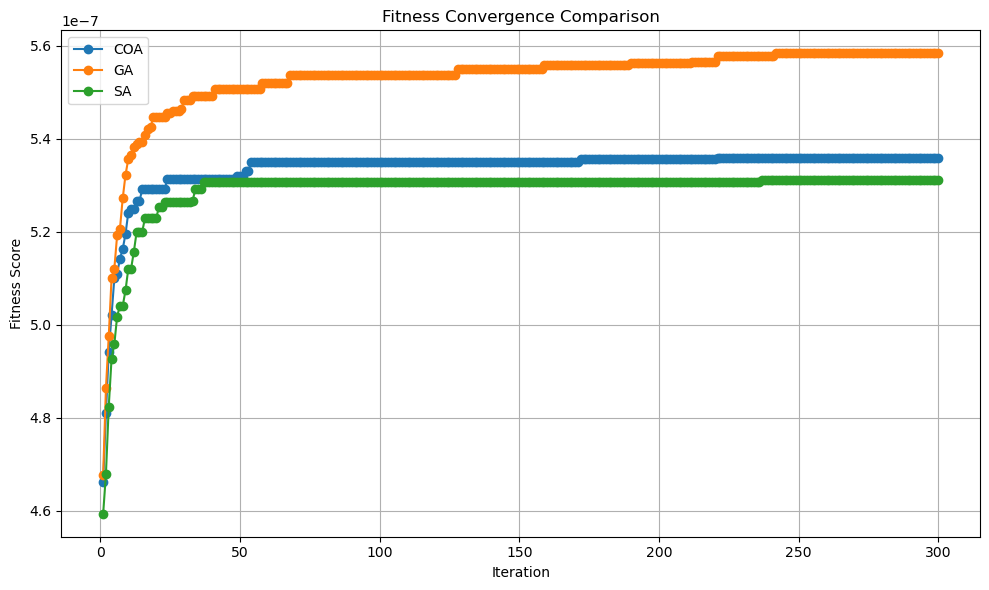

In [29]:
plt.figure(figsize=(10,6))

for r in results:
    if r['history']['fitness']:
        plt.plot(
            range(1, len(r['history']['fitness'])+1),
            r['history']['fitness'],
            label=r['name'],
            marker='o'
        )

plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.title("Fitness Convergence Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Save summary and representative schedule CSVs

In [30]:
def save_all_results_to_single_txt(results, filename):
    with open(filename, 'w') as f:
        f.write("=== SUMMARY REPORT - OPTIMIZATION RESULTS ===\n")
        f.write(f"Total Algorithms Tested: {len(results)}\n")
        f.write("="*45 + "\n\n")
    
    for i, result in enumerate(results):
        with open(filename, 'a') as f: 
            f.write(f"--- RESULT #{i+1}: {result['name']} ---\n")
            f.write(f"Best Fitness : {result['eval']['fitness']:}\n")
            f.write(f"Runtime      : {result['runtime']:.2f} sec\n")
            f.write(f"Status       : {'FEASIBLE' if result['eval']['is_feasible'] else 'NOT FEASIBLE'}\n")
            f.write(f"Heavy Penalty: {result['eval']['heavy_total']}\n")
            f.write(f"Light Penalty: {result['eval']['light_total']}\n\n")
            
            f.write("=== HEAVY DETAIL ===\n")
            if result['eval']['heavy_detail']:
                for k, v in result['eval']['heavy_detail'].items():
                    f.write(f"- {k}: {v}\n")
            else:
                f.write("No heavy penalties.\n")
                
            f.write("\n=== LIGHT DETAIL ===\n")
            if result['eval']['light_detail']:
                for k, v in result['eval']['light_detail'].items():
                    f.write(f"- {k}: {v}\n")
            else:
                f.write("No light penalties.\n")
            
            f.write("\n" + "="*45 + "\n\n")

filename = "all_reports_Gabungan.txt"
save_all_results_to_single_txt(results, filename)
print(f"Laporan lengkap dengan Fitness Score berhasil disimpan ke {filename}")

Laporan lengkap dengan Fitness Score berhasil disimpan ke all_reports_Gabungan.txt


In [31]:
rows = []

for r in results:
    sched = r['schedule']
    for k, sessions in sched.items():
        for sess in sessions:
            day, hour = available_slots[sess['slot']]
            rows.append({
                'Algorithm': r['name'],
                'Hari': day,
                'Jam': hour,
                'Prodi': courses[k]['prodi'],
                'Kode_MK': courses[k]['kode'],
                'Nama_MK': courses[k]['nama'],
                'Jenis': sess['type'],
                'Ruang': sess['room'],
                'Dosen': courses[k]['dosen'],
                'Fitness': r['eval']['fitness'],
                'Heavy_Total': r['eval']['heavy_total'],
                'Light_Total': r['eval']['light_total'],
                'Feasible': r['eval']['is_feasible']
            })

df_schedule_all = pd.DataFrame(rows)
df_schedule_all.to_csv("Gabungan_Schedules.csv", index=False)

# UJI NORMALITAS (SHAPIRO–WILK)

In [32]:
from scipy.stats import shapiro

fitness_values = [r['eval']['light_total'] for r in results if r['eval']['is_feasible']]
stat,p = shapiro(fitness_values)
print("Shapiro-Wilk Test")
print("Statistic:",stat)
print("p-value :",p)

if p > 0.05:
    print("Data berdistribusi NORMAL")
else:
    print("Data TIDAK normal")


Shapiro-Wilk Test
Statistic: nan
p-value : nan
Data TIDAK normal


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2544\503007618.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat,p = shapiro(fitness_values)
